# kNN — COVID-19 Mortality Prediction
## with 5-Fold Nested Cross-Validation (optimized for Recall)

**Pipeline:** `StandardScaler` → `SMOTE` → `KNeighborsClassifier`

**Evaluation strategy:**
- **Outer 5-fold CV** on the training set → unbiased generalization estimate (mean ± std for all metrics)
- **Inner 3-fold CV** (`GridSearchCV`) for hyperparameter tuning, scoring optimized for **recall**
- **Held-out test set** → used **once** at the end to report final performance

**Why recall?** In a mortality-prediction setting, a false negative (predicting "survives" when the patient actually died) is far more costly than a false positive. Recall (= sensitivity) directly measures the share of deceased patients we successfully flag.

**Why nested CV?** A single train/val split combined with hyperparameter tuning on the same fold leaks information and produces over-optimistic metrics. Nested CV decouples model selection (inner loop) from performance estimation (outer loop).


## 1. Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV,
    cross_validate,
)
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve,
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

import shap

RANDOM_STATE = 42
plt.rcParams.update({"font.size": 11})

# Directory where all plots will be saved
PLOTS_DIR = "kNN_plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

def save_plot(filename: str) -> None:
    """Save the current figure into PLOTS_DIR."""
    path = os.path.join(PLOTS_DIR, filename)
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print(f"  -> saved: {path}")


## 2. Configuration




In [2]:
# --- File paths (already pre-split, already 0/1 encoded) ---
PATHS = {
    "COVID_positive": {
        "X_train": "X_train_pos.csv",
        "y_train": "y_train_pos.csv",
        "X_test":  "X_test_pos.csv",
        "y_test":  "y_test_pos.csv",
    },
    "COVID_negative": {
        "X_train": "X_train_neg.csv",
        "y_train": "y_train_neg.csv",
        "X_test":  "X_test_neg.csv",
        "y_test":  "y_test_neg.csv",
    },
}

# --- Hyperparameter grid for kNN ---
PARAM_GRID = {"knn__n_neighbors": [3, 5, 7, 9, 11]}

# --- Metrics computed inside the outer CV loop ---
SCORING = {
    "accuracy":  "accuracy",
    "recall":    "recall",
    "precision": "precision",
    "f1":        "f1",
    "roc_auc":   "roc_auc",
}

# --- CV splitters (5 outer / 5 inner) ---
OUTER_CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
INNER_CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)


## 3. Data loading




In [3]:
def load_dataset(paths: dict) -> tuple:
    """Load one of the four pre-split datasets.

    Returns (X_train, y_train, X_test, y_test) — all dtype = int / float, no NaN.
    """
    X_train = pd.read_csv(paths["X_train"])
    y_train = pd.read_csv(paths["y_train"]).squeeze("columns").astype(int)
    X_test  = pd.read_csv(paths["X_test"])
    y_test  = pd.read_csv(paths["y_test"]).squeeze("columns").astype(int)

    # Cast boolean one-hot tobacco columns to 0/1
    for col in ("TOBACCO_1", "TOBACCO_3"):
        if col in X_train.columns:
            X_train[col] = X_train[col].astype(int)
            X_test[col]  = X_test[col].astype(int)

    return X_train, y_train, X_test, y_test


def describe_split(name, X_train, y_train, X_test, y_test):
    print(f">>> {name}")
    print("-" * 60)
    print(f"  X_train: {X_train.shape}    X_test: {X_test.shape}")
    print(f"  y_train class distribution: {y_train.value_counts().to_dict()}")
    print(f"  y_test  class distribution: {y_test.value_counts().to_dict()}")
    pos_rate_train = y_train.mean()
    pos_rate_test  = y_test.mean()
    print(f"  Positive (deceased) rate — train: {pos_rate_train:.3f}, test: {pos_rate_test:.3f}")
    print()


## 4. Pipeline

We use the **`imblearn` pipeline** so that **SMOTE only runs during `fit()`**, never during `predict()` or on validation folds — this is essential for a leak-free nested CV.

- `StandardScaler` — kNN is distance-based and therefore very sensitive to feature scales (AGE is on a very different scale than the 0/1 comorbidity flags)
- `SMOTE` — oversamples the minority class (deceased) *inside* each training fold only
- `KNeighborsClassifier` — the model whose `n_neighbors` we tune


In [4]:
def make_pipeline() -> Pipeline:
    return Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("smote",  SMOTE(random_state=RANDOM_STATE)),
        ("knn",    KNeighborsClassifier(n_jobs=-1)),
    ])


## 5. Nested cross-validation

For each of the 5 **outer** folds:
1. The inner `GridSearchCV` tunes `n_neighbors` on the outer-train portion, scored on **recall**.
2. The chosen pipeline is then evaluated on the outer-validation fold against every metric in `SCORING`.

The result is 5 unbiased recall / precision / F1 / ROC-AUC / accuracy estimates — we report their mean ± std.


In [5]:
def nested_cv(X_train: pd.DataFrame, y_train: pd.Series) -> dict:
    """Run 5-fold nested CV optimized for recall and return per-metric mean & std."""

    inner_search = GridSearchCV(
        estimator=make_pipeline(),
        param_grid=PARAM_GRID,
        scoring="recall",     # optimize hyperparameters for recall
        refit=True,
        cv=INNER_CV,
        n_jobs=-1,
        verbose=0,
    )

    # cross_validate wraps the inner search; for each outer fold it fits inner_search
    # on the outer-train data, then scores the resulting best estimator on the outer-validation fold.
    cv_results = cross_validate(
        estimator=inner_search,
        X=X_train,
        y=y_train,
        scoring=SCORING,
        cv=OUTER_CV,
        n_jobs=-1,
        return_estimator=True,
        verbose=0,
    )

    # Aggregate the 5 outer-fold scores into mean ± std
    summary = {
        metric: {
            "mean": float(np.mean(cv_results[f"test_{metric}"])),
            "std":  float(np.std(cv_results[f"test_{metric}"])),
            "folds": cv_results[f"test_{metric}"].tolist(),
        }
        for metric in SCORING
    }

    # Best k chosen in each outer fold (for transparency / stability check)
    best_ks = [est.best_params_["knn__n_neighbors"] for est in cv_results["estimator"]]
    summary["best_k_per_fold"] = best_ks

    return summary


def print_nested_summary(name: str, summary: dict) -> None:
    print(f"\n=== Nested CV summary — {name} ===")
    print(f"  Best k per outer fold: {summary['best_k_per_fold']}")
    print(f"  {'Metric':<10} {'Mean':>8}   {'Std':>8}     {'Per-fold scores'}")
    for m in SCORING:
        folds = ", ".join(f"{x:.4f}" for x in summary[m]['folds'])
        print(f"  {m:<10} {summary[m]['mean']:>8.4f} +/-{summary[m]['std']:>7.4f}    [{folds}]")


## 6. Final model

The nested CV above gives us the **unbiased performance estimate**.



In [6]:
def fit_final_and_evaluate(name, X_train, y_train, X_test, y_test) -> dict:
    """Refit a single GridSearchCV on all training data; evaluate on the held-out test set."""
    search = GridSearchCV(
        estimator=make_pipeline(),
        param_grid=PARAM_GRID,
        scoring="recall",
        refit=True,
        cv=INNER_CV,
        n_jobs=-1,
        verbose=0,
    )
    search.fit(X_train, y_train)
    best_pipe = search.best_estimator_

    y_pred  = best_pipe.predict(X_test)
    y_proba = best_pipe.predict_proba(X_test)[:, 1]

    test_metrics = {
        "best_k":    search.best_params_["knn__n_neighbors"],
        "accuracy":  accuracy_score(y_test, y_pred),
        "recall":    recall_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "f1":        f1_score(y_test, y_pred),
        "roc_auc":   roc_auc_score(y_test, y_proba),
    }

    print(f"\n=== Final model on held-out test set — {name} ===")
    print(f"  Best k (tuned on full training set, inner 5-fold CV): {test_metrics['best_k']}")
    print(f"  Accuracy : {test_metrics['accuracy']:.4f}")
    print(f"  Recall   : {test_metrics['recall']:.4f}")
    print(f"  Precision: {test_metrics['precision']:.4f}")
    print(f"  F1       : {test_metrics['f1']:.4f}")
    print(f"  ROC-AUC  : {test_metrics['roc_auc']:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    print("\n  Confusion matrix:")
    print("                pred=0   pred=1")
    print(f"    true=0  {cm[0,0]:>9}{cm[0,1]:>9}")
    print(f"    true=1  {cm[1,0]:>9}{cm[1,1]:>9}")
    print("\n  Classification report:")
    print(classification_report(y_test, y_pred,
                                target_names=["survived (0)", "deceased (1)"]))

    return {
        "name":          name,
        "pipeline":      best_pipe,
        "X_train":       X_train,
        "X_test":        X_test,
        "y_test":        y_test,
        "y_pred":        y_pred,
        "y_proba":       y_proba,
        "feature_names": list(X_train.columns),
        "test_metrics":  test_metrics,
    }


## 7.a) Run — COVID-positive dataset

In [7]:
X_train_p, y_train_p, X_test_p, y_test_p = load_dataset(PATHS["COVID_positive"])
describe_split("COVID_positive", X_train_p, y_train_p, X_test_p, y_test_p)


>>> COVID_positive
------------------------------------------------------------
  X_train: (90631, 14)    X_test: (22658, 14)
  y_train class distribution: {0: 47953, 1: 42678}
  y_test  class distribution: {0: 11988, 1: 10670}
  Positive (deceased) rate — train: 0.471, test: 0.471



In [ ]:
# Outer + inner 3-fold nested CV on the training set
summary_POS = nested_cv(X_train_p, y_train_p)
print_nested_summary("COVID_positive", summary_POS)



=== Nested CV summary — COVID_positive ===
  Best k per outer fold: [11, 11, 11, 11, 11]
  Metric         Mean        Std     Per-fold scores
  accuracy     0.6509 +/- 0.0047    [0.6466, 0.6587, 0.6500, 0.6534, 0.6458]
  recall       0.6695 +/- 0.0104    [0.6640, 0.6867, 0.6753, 0.6644, 0.6571]
  precision    0.6197 +/- 0.0041    [0.6157, 0.6253, 0.6173, 0.6239, 0.6162]
  f1           0.6436 +/- 0.0064    [0.6389, 0.6546, 0.6450, 0.6435, 0.6360]
  roc_auc      0.7045 +/- 0.0041    [0.6990, 0.7096, 0.7033, 0.7089, 0.7016]


In [9]:
# Final fit on full training set + single test-set evaluation
result_POS = fit_final_and_evaluate("COVID_positive",
                                     X_train_p, y_train_p, X_test_p, y_test_p)
result_POS["nested_cv"] = summary_POS



=== Final model on held-out test set — COVID_positive ===
  Best k (tuned on full training set, inner 5-fold CV): 9
  Accuracy : 0.6465
  Recall   : 0.6561
  Precision: 0.6173
  F1       : 0.6361
  ROC-AUC  : 0.6972

  Confusion matrix:
                pred=0   pred=1
    true=0       7648     4340
    true=1       3669     7001

  Classification report:
              precision    recall  f1-score   support

survived (0)       0.68      0.64      0.66     11988
deceased (1)       0.62      0.66      0.64     10670

    accuracy                           0.65     22658
   macro avg       0.65      0.65      0.65     22658
weighted avg       0.65      0.65      0.65     22658



## 7.b) Run — COVID-negative dataset

In [10]:
X_train_n, y_train_n, X_test_n, y_test_n = load_dataset(PATHS["COVID_negative"])
describe_split("COVID_negative", X_train_n, y_train_n, X_test_n, y_test_n)


>>> COVID_negative
------------------------------------------------------------
  X_train: (98592, 14)    X_test: (24649, 14)
  y_train class distribution: {0: 80499, 1: 18093}
  y_test  class distribution: {0: 20125, 1: 4524}
  Positive (deceased) rate — train: 0.184, test: 0.184



In [12]:
# Outer + inner 3-fold nested CV on the training set
summary_NEG = nested_cv(X_train_n, y_train_n)
print_nested_summary("COVID_negative", summary_NEG)



=== Nested CV summary — COVID_negative ===
  Best k per outer fold: [11, 11, 11, 11, 11]
  Metric         Mean        Std     Per-fold scores
  accuracy     0.7435 +/- 0.0030    [0.7433, 0.7488, 0.7440, 0.7413, 0.7401]
  recall       0.2316 +/- 0.0106    [0.2266, 0.2335, 0.2465, 0.2369, 0.2147]
  precision    0.2690 +/- 0.0091    [0.2661, 0.2794, 0.2775, 0.2680, 0.2540]
  f1           0.2489 +/- 0.0097    [0.2447, 0.2544, 0.2611, 0.2515, 0.2327]
  roc_auc      0.6567 +/- 0.0035    [0.6549, 0.6590, 0.6622, 0.6551, 0.6524]


In [13]:
# Final fit on full training set + single test-set evaluation
result_NEG = fit_final_and_evaluate("COVID_negative",
                                     X_train_n, y_train_n, X_test_n, y_test_n)
result_NEG["nested_cv"] = summary_NEG



=== Final model on held-out test set — COVID_negative ===
  Best k (tuned on full training set, inner 5-fold CV): 11
  Accuracy : 0.7498
  Recall   : 0.2182
  Precision: 0.2729
  F1       : 0.2425
  ROC-AUC  : 0.6534

  Confusion matrix:
                pred=0   pred=1
    true=0      17495     2630
    true=1       3537      987

  Classification report:
              precision    recall  f1-score   support

survived (0)       0.83      0.87      0.85     20125
deceased (1)       0.27      0.22      0.24      4524

    accuracy                           0.75     24649
   macro avg       0.55      0.54      0.55     24649
weighted avg       0.73      0.75      0.74     24649



## 8. Side-by-side comparison

The table below combines the **outer-CV mean ± std** (unbiased estimate) with the **single test-set score** (final reported number).


In [14]:
def build_summary_row(result):
    row = {"dataset": result["name"],
           "best_k_test": result["test_metrics"]["best_k"]}
    for m in SCORING:
        row[f"{m}_CVmean"] = result["nested_cv"][m]["mean"]
        row[f"{m}_CVstd"]  = result["nested_cv"][m]["std"]
        row[f"{m}_test"]   = result["test_metrics"][m]
    return row

summary_df = pd.DataFrame([
    build_summary_row(result_POS),
    build_summary_row(result_NEG),
])
print("=" * 90)
print("  COMPARISON — Nested CV (mean +/- std on training set) vs final test-set score")
print("=" * 90)
print(summary_df.round(4).to_string(index=False))


  COMPARISON — Nested CV (mean +/- std on training set) vs final test-set score
       dataset  best_k_test  accuracy_CVmean  accuracy_CVstd  accuracy_test  recall_CVmean  recall_CVstd  recall_test  precision_CVmean  precision_CVstd  precision_test  f1_CVmean  f1_CVstd  f1_test  roc_auc_CVmean  roc_auc_CVstd  roc_auc_test
COVID_positive            9           0.6509          0.0047         0.6465         0.6695        0.0104       0.6561            0.6197           0.0041          0.6173     0.6436    0.0064   0.6361          0.7045         0.0041        0.6972
COVID_negative           11           0.7435          0.0030         0.7498         0.2316        0.0106       0.2182            0.2690           0.0091          0.2729     0.2489    0.0097   0.2425          0.6567         0.0035        0.6534


## 9. ROC curves — both models

  -> saved: kNN_plots\kNN_roc_curve_comparison.png


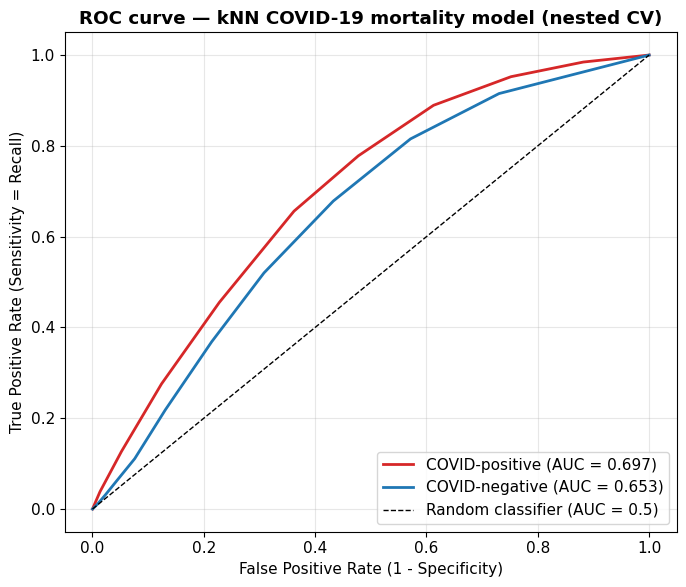

In [15]:
fpr_p, tpr_p, _ = roc_curve(result_POS["y_test"], result_POS["y_proba"])
fpr_n, tpr_n, _ = roc_curve(result_NEG["y_test"], result_NEG["y_proba"])
auc_p = result_POS["test_metrics"]["roc_auc"]
auc_n = result_NEG["test_metrics"]["roc_auc"]

plt.figure(figsize=(7, 6))
plt.plot(fpr_p, tpr_p, color="#d62728", linewidth=2,
         label=f"COVID-positive (AUC = {auc_p:.3f})")
plt.plot(fpr_n, tpr_n, color="#1f77b4", linewidth=2,
         label=f"COVID-negative (AUC = {auc_n:.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1,
         label="Random classifier (AUC = 0.5)")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity = Recall)")
plt.title("ROC curve — kNN COVID-19 mortality model (nested CV)",
          fontweight="bold")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
save_plot("kNN_roc_curve_comparison.png")
plt.show()


## 10. Precision-Recall curves — both models

The horizontal dotted lines mark the **baseline precision** (= positive-class prevalence in each test set). A useful model should sit above its own baseline.


  -> saved: kNN_plots\kNN_precision_recall_curve_comparison.png


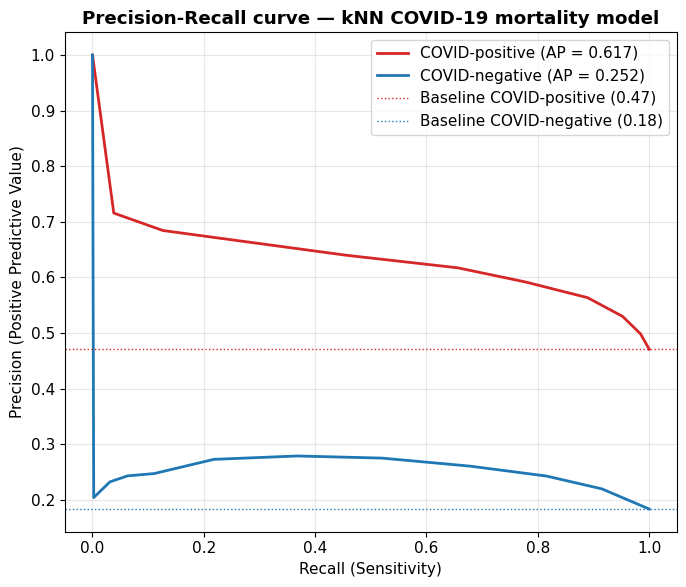

In [16]:
prec_p, rec_p, _ = precision_recall_curve(result_POS["y_test"], result_POS["y_proba"])
prec_n, rec_n, _ = precision_recall_curve(result_NEG["y_test"], result_NEG["y_proba"])
ap_p = average_precision_score(result_POS["y_test"], result_POS["y_proba"])
ap_n = average_precision_score(result_NEG["y_test"], result_NEG["y_proba"])

base_p = result_POS["y_test"].mean()
base_n = result_NEG["y_test"].mean()

plt.figure(figsize=(7, 6))
plt.plot(rec_p, prec_p, color="#d62728", linewidth=2,
         label=f"COVID-positive (AP = {ap_p:.3f})")
plt.plot(rec_n, prec_n, color="#1f77b4", linewidth=2,
         label=f"COVID-negative (AP = {ap_n:.3f})")
plt.axhline(base_p, color="#d62728", linestyle=":", linewidth=1,
            label=f"Baseline COVID-positive ({base_p:.2f})")
plt.axhline(base_n, color="#1f77b4", linestyle=":", linewidth=1,
            label=f"Baseline COVID-negative ({base_n:.2f})")
plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision (Positive Predictive Value)")
plt.title("Precision-Recall curve — kNN COVID-19 mortality model",
          fontweight="bold")
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.tight_layout()
save_plot("kNN_precision_recall_curve_comparison.png")
plt.show()


## 11. Confusion matrices — heatmap view

  -> saved: kNN_plots\kNN_confusion_matrices.png


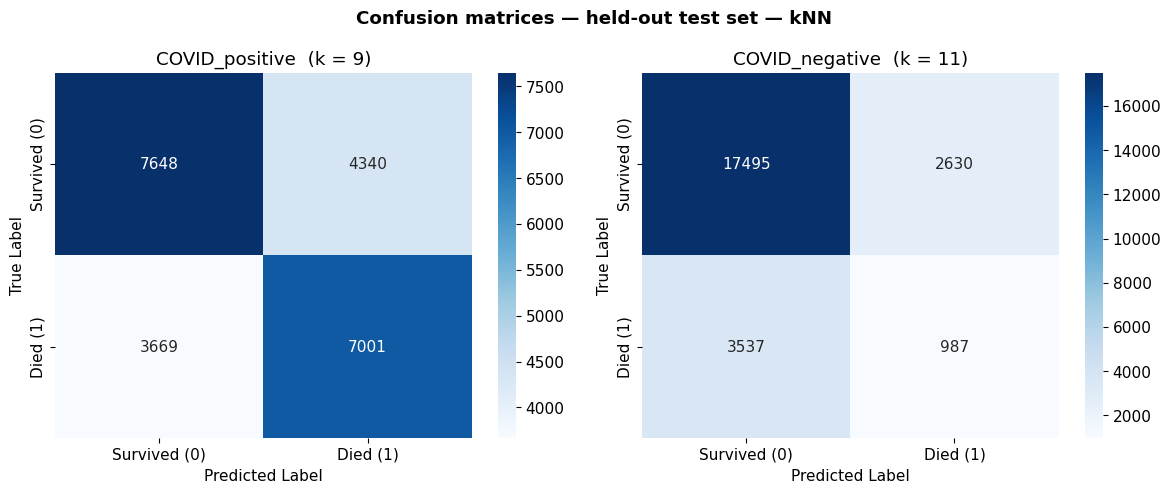

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, result in zip(axes, [result_POS, result_NEG]):
    cm = confusion_matrix(result["y_test"], result["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Survived (0)", "Died (1)"],
                yticklabels=["Survived (0)", "Died (1)"], ax=ax)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_title(f"{result['name']}  (k = {result['test_metrics']['best_k']})")

plt.suptitle("Confusion matrices — held-out test set — kNN", fontweight="bold")
plt.tight_layout()
save_plot("kNN_confusion_matrices.png")
plt.show()


## 12. SHAP feature importance

`KernelExplainer` is model-agnostic but slow — it is therefore evaluated only on a small random sample.


In [18]:
def run_shap(result: dict, save_suffix: str,
             n_background: int = 50, n_eval: int = 100,
             nsamples: int = 100):
    """Apply SHAP KernelExplainer to the trained pipeline model."""
    name       = result["name"]
    pipe       = result["pipeline"]
    X_train    = result["X_train"]
    X_test     = result["X_test"]
    feat_names = result["feature_names"]

    print(f"\n>>> SHAP analysis for {name}")
    print(f"  background={n_background}, evaluation={n_eval}, nsamples={nsamples}")

    def predict_proba_died(arr):
        if not isinstance(arr, pd.DataFrame):
            arr = pd.DataFrame(arr, columns=feat_names)
        return pipe.predict_proba(arr)[:, 1]

    background = shap.sample(X_train, n_background, random_state=RANDOM_STATE)
    X_eval     = X_test.sample(n=n_eval, random_state=RANDOM_STATE)

    explainer   = shap.KernelExplainer(predict_proba_died, background)
    shap_values = explainer.shap_values(X_eval, nsamples=nsamples, silent=False)

    plt.figure()
    shap.summary_plot(shap_values, X_eval, feature_names=feat_names, show=False)
    plt.title(f"SHAP summary — {name}")
    plt.tight_layout()
    save_plot(f"kNN_shap_summary_{save_suffix}.png")
    plt.show()

    return shap_values



>>> SHAP analysis for COVID_positive
  background=50, evaluation=100, nsamples=100


100%|██████████| 100/100 [07:58<00:00,  4.79s/it]


  -> saved: kNN_plots\kNN_shap_summary_POS.png


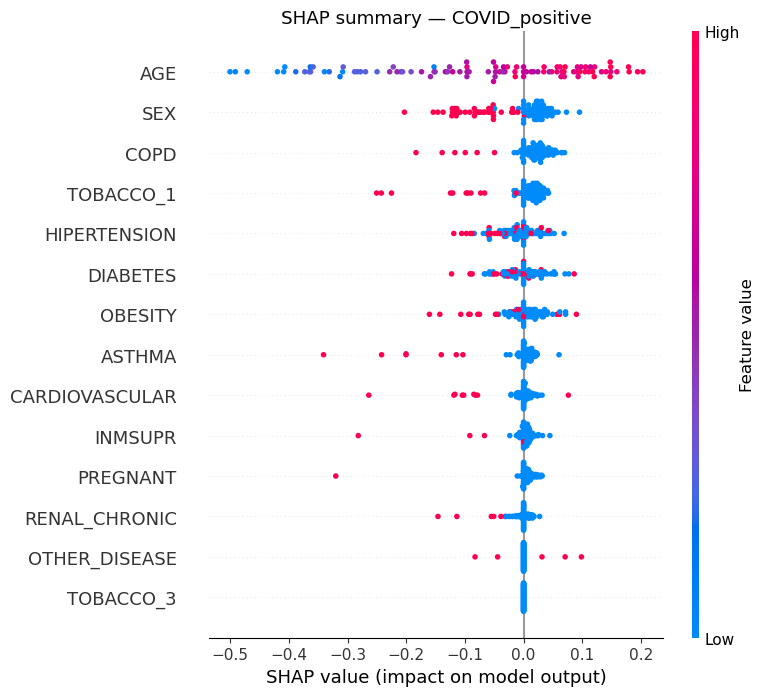

In [19]:
# SHAP — COVID-positive (slow, ~5 min)
shap_POS = run_shap(result_POS, save_suffix="POS",
                    n_background=50, n_eval=100, nsamples=100)



>>> SHAP analysis for COVID_negative
  background=50, evaluation=100, nsamples=100


100%|██████████| 100/100 [06:56<00:00,  4.16s/it]


  -> saved: kNN_plots\kNN_shap_summary_NEG.png


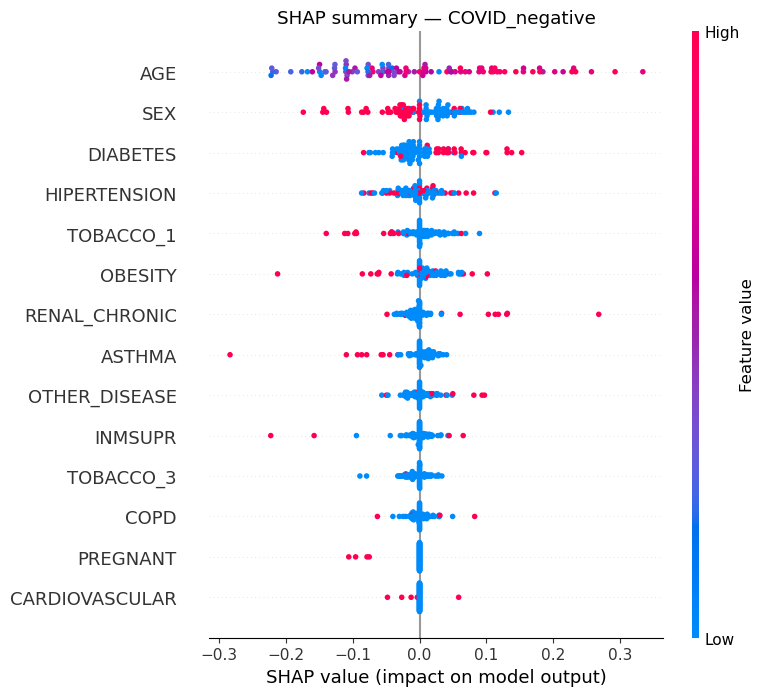

In [19]:
# SHAP — COVID-negative (slow, ~5 min)
shap_NEG = run_shap(result_NEG, save_suffix="NEG",
                    n_background=50, n_eval=100, nsamples=100)


## 13. Notes & interpretation

- **Recall is the primary metric.** Because we tune k on recall, the resulting models intentionally err on the side of flagging more patients as high-risk — the trade-off is lower precision.
- **Best-k stability.** The list `best_k_per_fold` shows which k was chosen in each outer fold. If all five folds pick the same k, the choice is robust; if they vary a lot, the kNN decision boundary in this dataset is sensitive and recall is probably similar across several k values.
- **Class imbalance.** SMOTE inside the pipeline addresses the strong class imbalance (especially in the COVID-negative subset, where deaths are rare). Because SMOTE only runs in `fit()`, the test set is never contaminated with synthetic samples.
